In [1]:
import numpy as np
import cloudvolume
from tqdm import tqdm
import glob
import os
import json

In [2]:
# EM 
em_seg_batch_paths = [
    [   # mrgd dataset .. ignore
        "precomputed://gs://htem_dorsalhorn_mrgd_r1093/dorsal_sections/dorsal_sections_0-500",
        "graphene://https://cave.fanc-fly.com/segmentation/table/mouse_dorsal_spine"
    ],
    [   # spinal-cord dataset
        "precomputed://gs://lee-mouse-spinal-cord-001-raw/sharded",
        "graphene://https://cave.fanc-fly.com/segmentation/table/wclee_mouse_spinalcord_cltmr"
    ]
]

DATASET_IDX = 1
MIP = (32,32,45)

em_path = em_seg_batch_paths[DATASET_IDX][0]
seg_path = em_seg_batch_paths[DATASET_IDX][1]

spinalcord_em = cloudvolume.CloudVolume(em_path, use_https=True, 
                                  fill_missing=True,
                                  mip=MIP,
                                  progress=False)
# SEG
spinalcord_seg = cloudvolume.CloudVolume(seg_path, 
                                   use_https=True, #secrets='REPLACE_WITH_YOUR_CAVE_TOKEN', 
                                   mip=MIP, 
                                   agglomerate=True, # for rootids
                                   progress=False)


In [3]:
def get_seg_id_from_coord(coord, seg_mip=(32,32,45), coordinate_mip=(32,32,45)):

    mip_scale = np.array(seg_mip)/np.array(coordinate_mip)
    seg_coord = (coord[0]//mip_scale[0], coord[1]//mip_scale[1], coord[2]//mip_scale[2])
    
    voxel_seg_id = spinalcord_seg[seg_coord] # segmentation ID of neuron coordinate
    return voxel_seg_id

In [4]:
import pandas as pd
from pathlib import Path
import re

# === Setup ===
folder_path = Path('/Users/wangchu/v3/v4/v4_gnn/v4_gnn')

# Define all cell types you want columns for (include low_confidence_sensory)
cell_types = ['Aδ-HTMR', 'C-Cold', 'C-HTMR', 'C-HTMR-Non-peptidergic',
              'C-Heat', 'N/A', 'Aβ-LTMR', 'Aδ-LTMR', 'C-LTMR', 'low_confidence_sensory']

# Classifier columns used to assess low-confidence sensory identity
classifier_column = ['cltmr', 'abltmr', 'adltmr', 'chtmrnp',
                   'c-htmr', 'adhtmrp', 'cheat', 'cold']

# Regex pattern to extract coordinates from filename
pattern = re.compile(r'cell_type_predictions_(\d+)_(\d+)_(\d+)\.feather')

# === Build rows ===
rows = []

for feather_file in folder_path.glob('cell_type_predictions_*.feather'):
    match = pattern.search(feather_file.name)
    if not match:
        continue

    x, y, z = map(int, match.groups())
    vol = get_seg_id_from_coord((x, y, z), seg_mip=(32, 32, 45), coordinate_mip=(32, 32, 45))
    root_id = int(vol[0, 0, 0, 0])

    df = pd.read_feather(feather_file)

    # Create mask for is_sensory == True
    is_sensory_mask = df['is_sensory'] == True

    # Create mask for all classifier values <= 0.9
    low_confidence_mask = (df[classifier_column] <= 0.6).all(axis=1)

    # Combine masks
    final_mask = is_sensory_mask & low_confidence_mask

    # Update 'cell_type' for those rows
    df.loc[final_mask, 'cell_type'] = 'low_confidence_sensory'
    # Step 2: Count cell_type occurrences
    synapse_counts = df['cell_type'].value_counts().to_dict()

    # Step 3: Build row for result_df
    row_data = {ct: synapse_counts.get(ct, 0) for ct in cell_types}
    row_data['neuron_id'] = root_id
    rows.append(row_data)

# === Create result_df ===
result_df = pd.DataFrame(rows).set_index('neuron_id')
print(result_df.head())


                    Aδ-HTMR  C-Cold  C-HTMR  C-HTMR-Non-peptidergic  C-Heat  \
neuron_id                                                                     
720575940905042134        8       7       1                      10      13   
720575940892190818        1       0       2                       6       3   
720575940882124516        2       0       0                      33       0   
720575940893395733       14       0       5                     778       8   
720575940940386475       15      34       3                       1      12   

                     N/A  Aβ-LTMR  Aδ-LTMR  C-LTMR  low_confidence_sensory  
neuron_id                                                                   
720575940905042134  2967        2        0       2                      14  
720575940892190818   991       70      419      46                      12  
720575940882124516   620        1        2     704                       7  
720575940893395733  1168        0        0      15           

In [9]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')
cell_type = client.materialize.query_table('spinalcord_neuron_clusters_2')

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [10]:
# Ensure IDs are strings
cell_type['pt_root_id'] = cell_type['pt_root_id'].astype(str)
result_df.index = result_df.index.astype(str)

# Build base mapping from pt_root_id to tag
id_to_tag = dict(zip(cell_type['pt_root_id'], cell_type['tag']))

# Override mapping for one neuron
id_to_tag['720575940884925028'] = 'r'

# Map each root_id in result_df to its tag
result_df['cell_type'] = result_df.index.map(id_to_tag)



In [11]:
result_df

,Aδ-HTMR,C-Cold,C-HTMR,C-HTMR-Non-peptidergic,C-Heat,N/A,Aβ-LTMR,Aδ-LTMR,C-LTMR,low_confidence_sensory,cell_type
neuron_id,,,,,,,,,,,
720575940905042134,8,7,1,10,13,2967,2,0,2,14,v2
720575940892190818,1,0,2,6,3,991,70,419,46,12,NaN
720575940882124516,2,0,0,33,0,620,1,2,704,7,NaN
720575940893395733,14,0,5,778,8,1168,0,0,15,17,np_module
720575940940386475,15,34,3,1,12,4819,8,6,15,24,p1
...,...,...,...,...,...,...,...,...,...,...,...
720575940915578005,30,7,0,3,8,2495,13,7,2,6,v1
720575940896736698,45,0,46,249,68,1202,0,0,28,55,np_module
720575940905042902,36,1,83,32,30,1027,0,7,4,17,r


Saved SVG to: /Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/v1_v2_sensory_fraction_violin.svg


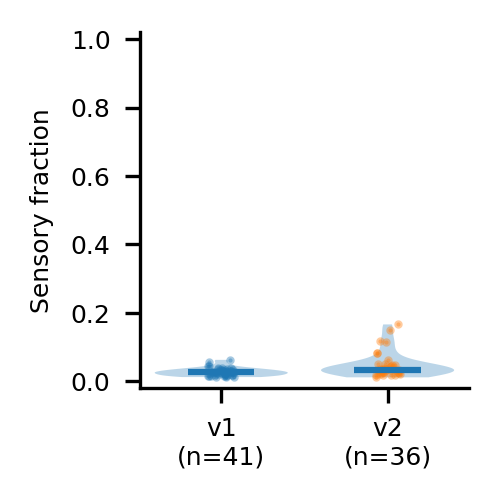

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Config (edit as needed)
# ---------------------------------------------------------
SAVE_SVG = True
SVG_PATH = "/Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/v1_v2_sensory_fraction_violin.svg"

# Figure size: 4 cm x 4 cm
CM_TO_INCH = 1 / 2.54
FIG_W_IN = 4 * CM_TO_INCH
FIG_H_IN = 4 * CM_TO_INCH

# ---------------------------------------------------------
# 1) Compute sensory fraction
# ---------------------------------------------------------
df = result_df.copy()

# Make sure inputs are numeric
input_cols = [c for c in df.columns if c != "cell_type"]
df[input_cols] = df[input_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Sensory columns = everything except 'cell_type' and 'N/A'
if "N/A" in df.columns:
    sensory_cols = [c for c in df.columns if c not in ("cell_type", "N/A")]
    df["non_sensory_input"] = df["N/A"]
else:
    sensory_cols = [c for c in df.columns if c != "cell_type"]
    df["non_sensory_input"] = 0

df["sensory_input_sum"] = df[sensory_cols].sum(axis=1)
df["total_input_sum"] = df["sensory_input_sum"] + df["non_sensory_input"]

df["sensory_fraction"] = np.where(
    df["total_input_sum"] > 0,
    df["sensory_input_sum"] / df["total_input_sum"],
    np.nan
)

# ---------------------------------------------------------
# 2) Violin plot: v1 vs v2 (4cm x 4cm)
# ---------------------------------------------------------
plot_df = df[df["cell_type"].isin(["v1", "v2"])].dropna(subset=["sensory_fraction"]).copy()

order = ["v1", "v2"]
data = [plot_df.loc[plot_df["cell_type"] == ct, "sensory_fraction"].values for ct in order]

fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN), dpi=300)

ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

# Overlay points (small, for a 4cm figure)
rng = np.random.default_rng(0)
for i, ct in enumerate(order, start=1):
    y = plot_df.loc[plot_df["cell_type"] == ct, "sensory_fraction"].values
    x = i + rng.uniform(-0.08, 0.08, size=len(y))
    ax.scatter(x, y, s=1, alpha=0.4)

# Labels / formatting (kept compact for 4cm)
n_v1 = int((plot_df["cell_type"] == "v1").sum())
n_v2 = int((plot_df["cell_type"] == "v2").sum())

ax.set_xticks([1, 2])
ax.set_xticklabels([f"v1\n(n={n_v1})", f"v2\n(n={n_v2})"], fontsize=6)
ax.set_ylabel("Sensory fraction", fontsize=6)
ax.set_ylim(-0.02, 1.02)

ax.tick_params(axis="y", labelsize=6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=0.4)

if SAVE_SVG:
    fig.savefig(SVG_PATH, format="svg", bbox_inches="tight")
    print("Saved SVG to:", SVG_PATH)

plt.show()


min/max sensory_fraction: 0.01129032258064516 0.16600265604249667

v1: n=41
  zeros: 0.000  | ones: 0.000
  mean=0.0272, median=0.0263
  skew=1.046  (rough; can be huge if many zeros)
  unique values: 41 (1.00 per point)

v2: n=36
  zeros: 0.000  | ones: 0.000
  mean=0.0472, median=0.0339
  skew=1.913  (rough; can be huge if many zeros)
  unique values: 36 (1.00 per point)


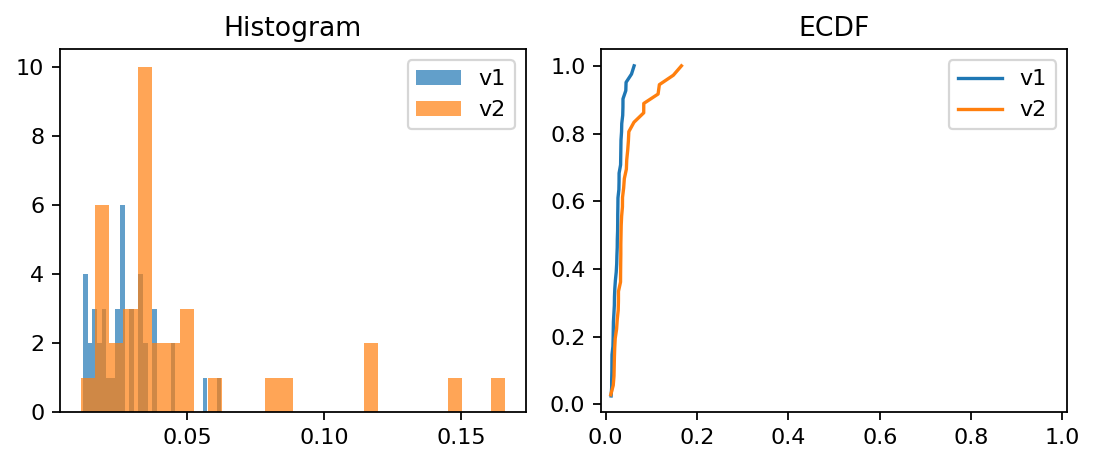


Total input sums:
  v1 median/mean: 2678.0 2716.0243902439024
  v2 median/mean: 2430.5 2530.1111111111113
  MWU on totals p= 0.1543664253866272


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- assumes df already has: cell_type, sensory_fraction, sensory_input_sum, total_input_sum ---
plot_df = df[df["cell_type"].isin(["v1", "v2"])].copy()
plot_df = plot_df.dropna(subset=["sensory_fraction"])

# sanity: bounded?
print("min/max sensory_fraction:", plot_df["sensory_fraction"].min(), plot_df["sensory_fraction"].max())

# group arrays
v1 = plot_df.loc[plot_df["cell_type"]=="v1", "sensory_fraction"].to_numpy()
v2 = plot_df.loc[plot_df["cell_type"]=="v2", "sensory_fraction"].to_numpy()

def describe_group(x, name):
    x = np.asarray(x)
    print(f"\n{name}: n={x.size}")
    print(f"  zeros: {np.mean(x==0):.3f}  | ones: {np.mean(x==1):.3f}")
    print(f"  mean={x.mean():.4f}, median={np.median(x):.4f}")
    print(f"  skew={stats.skew(x):.3f}  (rough; can be huge if many zeros)")
    # ties density (how many unique values)
    print(f"  unique values: {np.unique(x).size} ({np.unique(x).size/x.size:.2f} per point)")

describe_group(v1, "v1")
describe_group(v2, "v2")

# quick visuals
fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=160)
ax[0].hist(v1, bins=30, alpha=0.7, label="v1")
ax[0].hist(v2, bins=30, alpha=0.7, label="v2")
ax[0].set_title("Histogram")
ax[0].legend()

# ECDF (better than histogram for fractions w/ ties)
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x)+1)/len(x)
    return x, y
x1,y1 = ecdf(v1); x2,y2 = ecdf(v2)
ax[1].plot(x1, y1, label="v1")
ax[1].plot(x2, y2, label="v2")
ax[1].set_title("ECDF")
ax[1].set_xlim(-0.01, 1.01)
ax[1].legend()

plt.tight_layout()
plt.show()

# also check if totals differ systematically (important!):
tot_v1 = plot_df.loc[plot_df["cell_type"]=="v1", "total_input_sum"].to_numpy()
tot_v2 = plot_df.loc[plot_df["cell_type"]=="v2", "total_input_sum"].to_numpy()
print("\nTotal input sums:")
print("  v1 median/mean:", np.median(tot_v1), tot_v1.mean())
print("  v2 median/mean:", np.median(tot_v2), tot_v2.mean())
print("  MWU on totals p=", stats.mannwhitneyu(tot_v1, tot_v2, alternative="two-sided").pvalue)


In [15]:
import numpy as np
from scipy import stats

# v1, v2 arrays as before
v1 = plot_df.loc[plot_df["cell_type"]=="v1", "sensory_fraction"].to_numpy()
v2 = plot_df.loc[plot_df["cell_type"]=="v2", "sensory_fraction"].to_numpy()

print(f"n(v1)={v1.size}, n(v2)={v2.size}")
print(f"median(v1)={np.median(v1):.4f}, median(v2)={np.median(v2):.4f}")
print(f"mean(v1)={v1.mean():.4f},   mean(v2)={v2.mean():.4f}")

# -------------------------
# Primary: Brunner–Munzel
# -------------------------
bm = stats.brunnermunzel(v1, v2, alternative="two-sided")
print("\nBrunner–Munzel (two-sided):")
print(f"  W = {bm.statistic:.3g}, p = {bm.pvalue:.4g}")

# -------------------------
# Secondary: Mann–Whitney U
# -------------------------
u = stats.mannwhitneyu(v1, v2, alternative="two-sided")
print("\nMann–Whitney U (two-sided):")
print(f"  U = {u.statistic:.3g}, p = {u.pvalue:.4g}")

# -------------------------
# Effect size: Cliff's delta (directional)
# delta = P(v2>v1) - P(v2<v1)
# (positive => v2 tends larger than v1)
# -------------------------
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    # delta = P(x>y) - P(x<y)
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (x.size * y.size)

delta_v2_minus_v1 = cliffs_delta(v2, v1)
print("\nCliff's delta (v2 - v1):")
print(f"  delta = {delta_v2_minus_v1:.3f}  (positive means v2 > v1)")

# -------------------------
# Optional: Hodges–Lehmann estimator (median shift)
# robust "typical difference" v2 - v1
# -------------------------
hl = stats.mstats.hdquantiles(np.subtract.outer(v2, v1).ravel(), prob=[0.5])[0]
print("\nHodges–Lehmann median shift (v2 - v1):")
print(f"  HL = {float(hl):.4f}")


n(v1)=41, n(v2)=36
median(v1)=0.0263, median(v2)=0.0339
mean(v1)=0.0272,   mean(v2)=0.0472

Brunner–Munzel (two-sided):
  W = 3.48, p = 0.0008741

Mann–Whitney U (two-sided):
  U = 431, p = 0.001753

Cliff's delta (v2 - v1):
  delta = 0.416  (positive means v2 > v1)

Hodges–Lehmann median shift (v2 - v1):
  HL = 0.0098


HTMR-related columns found: ['Aδ-HTMR']
n(v1)=41, n(v2)=36
median(v1)=14, median(v2)=24
mean(v1)=18.7,   mean(v2)=42.8
zeros v1=0.000, zeros v2=0.000


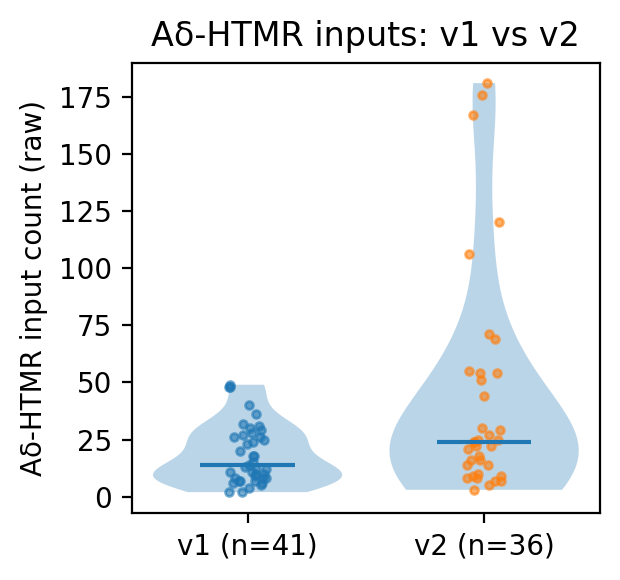


Brunner–Munzel (two-sided):
  W=2.33, p=0.02283
Mann–Whitney U (two-sided):
  U=519, p=0.02562


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- assumes result_df is your original dataframe ---
# columns: 'cell_type', 'N/A', and sensory classes including 'Aδ-HTMR' (or similar)

# -----------------------------
# 0) pick the correct column name
# -----------------------------
# If you're not 100% sure the column is exactly "Aδ-HTMR", this will find it robustly.
candidates = [c for c in result_df.columns if isinstance(c, str) and ("HTMR" in c) and ("A" in c)]
print("HTMR-related columns found:", candidates)

# Set this to the exact column you want:
COL_AD_HTMR = "Aδ-HTMR"  # <- change if needed (e.g. "Aδ-HTMR + C-Heat", "Aδ-HTMR (mono)", etc.)
assert COL_AD_HTMR in result_df.columns, f"Column '{COL_AD_HTMR}' not found. Use one of: {candidates}"

# -----------------------------
# 1) prepare plotting df
# -----------------------------
tmp = result_df.copy()
tmp = tmp[tmp["cell_type"].isin(["v1", "v2"])].copy()

tmp[COL_AD_HTMR] = pd.to_numeric(tmp[COL_AD_HTMR], errors="coerce").fillna(0)

v1 = tmp.loc[tmp["cell_type"] == "v1", COL_AD_HTMR].to_numpy()
v2 = tmp.loc[tmp["cell_type"] == "v2", COL_AD_HTMR].to_numpy()

print(f"n(v1)={v1.size}, n(v2)={v2.size}")
print(f"median(v1)={np.median(v1):.3g}, median(v2)={np.median(v2):.3g}")
print(f"mean(v1)={v1.mean():.3g},   mean(v2)={v2.mean():.3g}")
print(f"zeros v1={np.mean(v1==0):.3f}, zeros v2={np.mean(v2==0):.3f}")

# -----------------------------
# 2) violin plot (raw counts)
# -----------------------------
fig, ax = plt.subplots(figsize=(3.2, 3.0), dpi=200)

data = [v1, v2]
parts = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# overlay points w/ jitter
rng = np.random.default_rng(0)
for i, y in enumerate(data, start=1):
    x = i + rng.uniform(-0.08, 0.08, size=len(y))
    ax.scatter(x, y, s=8, alpha=0.6)

ax.set_xticks([1, 2])
ax.set_xticklabels([f"v1 (n={len(v1)})", f"v2 (n={len(v2)})"])
ax.set_ylabel(f"{COL_AD_HTMR} input count (raw)")
ax.set_title(f"{COL_AD_HTMR} inputs: v1 vs v2")

plt.tight_layout()
plt.show()

# -----------------------------
# 3) stats: pick based on structure (counts often skew / zero-inflated)
# -----------------------------
# If there are many zeros, do a hurdle-style report:
#   (i) Fisher exact for zero rate
#   (ii) Brunner–Munzel (or MWU) for positives only
z1, z2 = np.sum(v1 == 0), np.sum(v2 == 0)
if (z1 > 0) or (z2 > 0):
    from scipy.stats import fisher_exact
    oddsratio, p_zero = fisher_exact([[z1, len(v1)-z1], [z2, len(v2)-z2]], alternative="two-sided")
    print("\nZero-rate difference (Fisher exact):")
    print(f"  table=[[{z1},{len(v1)-z1}],[{z2},{len(v2)-z2}]]  p={p_zero:.4g}")

    v1_pos = v1[v1 > 0]
    v2_pos = v2[v2 > 0]
    if (len(v1_pos) >= 5) and (len(v2_pos) >= 5):
        bm_pos = stats.brunnermunzel(v1_pos, v2_pos, alternative="two-sided")
        print("Positives-only Brunner–Munzel:")
        print(f"  W={bm_pos.statistic:.3g}, p={bm_pos.pvalue:.4g}")
    else:
        print("Not enough positive values in one group for positives-only BM.")
else:
    # No zero inflation: Brunner–Munzel as primary (robust to unequal variances)
    bm = stats.brunnermunzel(v1, v2, alternative="two-sided")
    print("\nBrunner–Munzel (two-sided):")
    print(f"  W={bm.statistic:.3g}, p={bm.pvalue:.4g}")

    # Secondary MWU
    u = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    print("Mann–Whitney U (two-sided):")
    print(f"  U={u.statistic:.3g}, p={u.pvalue:.4g}")


HTMR-like columns: ['Aδ-HTMR']

v1: n=41
  min/max: 2 / 49
  mean=18.7, median=14, var=172
  zeros: 0.000
  var/mean (overdispersion hint): 9.19

v2: n=36
  min/max: 3 / 181
  mean=42.8, median=24, var=2.36e+03
  zeros: 0.000
  var/mean (overdispersion hint): 55.1
Saved SVG to: /Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/v1_v2_adhtmr_violin.svg


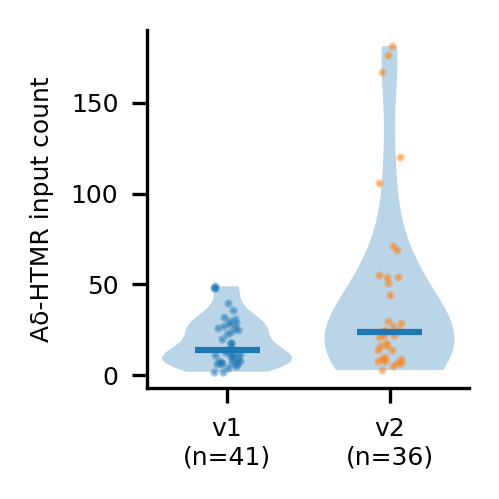


=== Significance testing (auto-picked) ===
Brunner–Munzel (primary): W=2.33, p=0.02283
Mann–Whitney U (secondary): U=519, p=0.02562
Cliff's delta (v2-v1)=0.297  (positive => v2 higher)
Hodges–Lehmann shift (v2-v1)=8.36

Overdispersion hint (var/mean) on pooled counts: 44.2

Negative Binomial GLM (v2 vs v1):
  log(RR)=0.83  => RR=2.29
  95% CI RR=(1.5, 3.5)
  p=0.0001173


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------
# Config (edit as needed)
# ---------------------------------------------------------
SAVE_SVG = True
SVG_PATH = "/Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/v1_v2_adhtmr_violin.svg"

# Figure size: 4 cm x 4 cm
CM_TO_INCH = 1 / 2.54
FIG_W_IN = 4 * CM_TO_INCH
FIG_H_IN = 4 * CM_TO_INCH

# -----------------------------
# Assumes:
#   result_df index = neuron id
#   result_df has column 'cell_type' with 'v1'/'v2'
#   result_df has a column for Aδ-HTMR inputs (raw counts)
# -----------------------------

# 0) Find the Aδ-HTMR column robustly (no guessing)
ad_candidates = [c for c in result_df.columns
                 if isinstance(c, str) and ("HTMR" in c) and ("A" in c)]
print("HTMR-like columns:", ad_candidates)

COL = "Aδ-HTMR"  # <- set this to the exact one you want
assert COL in result_df.columns, f"Column '{COL}' not found. Choose from: {ad_candidates}"

# 1) Build v1/v2 arrays (raw counts)
tmp = result_df[result_df["cell_type"].isin(["v1", "v2"])].copy()
tmp[COL] = pd.to_numeric(tmp[COL], errors="coerce").fillna(0).astype(float)

v1 = tmp.loc[tmp["cell_type"] == "v1", COL].to_numpy()
v2 = tmp.loc[tmp["cell_type"] == "v2", COL].to_numpy()

# 2) Check structure
def summarize_counts(x, name):
    x = np.asarray(x)
    print(f"\n{name}: n={x.size}")
    print(f"  min/max: {x.min():.3g} / {x.max():.3g}")
    print(f"  mean={x.mean():.3g}, median={np.median(x):.3g}, var={x.var(ddof=1):.3g}")
    print(f"  zeros: {np.mean(x==0):.3f}")
    if x.mean() > 0:
        print(f"  var/mean (overdispersion hint): {(x.var(ddof=1)/x.mean()):.3g}")

summarize_counts(v1, "v1")
summarize_counts(v2, "v2")

# 3) Violin plot (4cm x 4cm) + jitter
fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN), dpi=300)

ax.violinplot([v1, v2],
              positions=[1, 2],
              widths=0.8,
              showmeans=False,
              showmedians=True,
              showextrema=False)

rng = np.random.default_rng(0)
ax.scatter(1 + rng.uniform(-0.08, 0.08, size=len(v1)), v1, s=1, alpha=0.4)
ax.scatter(2 + rng.uniform(-0.08, 0.08, size=len(v2)), v2, s=1, alpha=0.4)

ax.set_xticks([1, 2])
ax.set_xticklabels([f"v1\n(n={len(v1)})", f"v2\n(n={len(v2)})"], fontsize=6)
ax.set_ylabel(f"{COL} input count", fontsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional title (often too cramped for 4cm figures); comment out if you want
# ax.set_title(f"{COL}", fontsize=6)

plt.tight_layout(pad=0.4)

if SAVE_SVG:
    fig.savefig(SVG_PATH, format="svg", bbox_inches="tight")
    print("Saved SVG to:", SVG_PATH)

plt.show()

# -----------------------------
# 4) Choose a proper test based on structure
# -----------------------------
z1, z2 = np.sum(v1 == 0), np.sum(v2 == 0)
zero_rate_1, zero_rate_2 = z1/len(v1), z2/len(v2)

print("\n=== Significance testing (auto-picked) ===")

def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (x.size * y.size)

if (z1 > 0) or (z2 > 0):
    from scipy.stats import fisher_exact
    oddsratio, p_zero = fisher_exact([[z1, len(v1)-z1], [z2, len(v2)-z2]], alternative="two-sided")
    print(f"Zero rate: v1={zero_rate_1:.3f}, v2={zero_rate_2:.3f}")
    print(f"Fisher exact on zeros: p = {p_zero:.4g}")

    v1_pos = v1[v1 > 0]
    v2_pos = v2[v2 > 0]
    if (len(v1_pos) >= 5) and (len(v2_pos) >= 5):
        bm = stats.brunnermunzel(v1_pos, v2_pos, alternative="two-sided")
        u = stats.mannwhitneyu(v1_pos, v2_pos, alternative="two-sided")
        d = cliffs_delta(v2_pos, v1_pos)
        hl = stats.mstats.hdquantiles(np.subtract.outer(v2_pos, v1_pos).ravel(), prob=[0.5])[0]
        print("\nPositives-only comparison:")
        print(f"  Brunner–Munzel: W={bm.statistic:.3g}, p={bm.pvalue:.4g}")
        print(f"  Mann–Whitney U: U={u.statistic:.3g}, p={u.pvalue:.4g}")
        print(f"  Cliff's delta (v2-v1)={d:.3f}")
        print(f"  Hodges–Lehmann shift (v2-v1)={float(hl):.3g}")
    else:
        print("Not enough positive values in one group for a positives-only distribution test.")
else:
    bm = stats.brunnermunzel(v1, v2, alternative="two-sided")
    u = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    d = cliffs_delta(v2, v1)
    hl = stats.mstats.hdquantiles(np.subtract.outer(v2, v1).ravel(), prob=[0.5])[0]
    print(f"Brunner–Munzel (primary): W={bm.statistic:.3g}, p={bm.pvalue:.4g}")
    print(f"Mann–Whitney U (secondary): U={u.statistic:.3g}, p={u.pvalue:.4g}")
    print(f"Cliff's delta (v2-v1)={d:.3f}  (positive => v2 higher)")
    print(f"Hodges–Lehmann shift (v2-v1)={float(hl):.3g}")

# -----------------------------
# 5) Optional: Negative Binomial GLM for overdispersed counts
# -----------------------------
try:
    import statsmodels.api as sm

    y = tmp[COL].astype(int).values
    x = (tmp["cell_type"] == "v2").astype(int).values
    X = sm.add_constant(x)

    mu = y.mean()
    var = y.var(ddof=1)
    overdisp = (var / mu) if mu > 0 else np.nan
    print(f"\nOverdispersion hint (var/mean) on pooled counts: {overdisp:.3g}")

    nb = sm.GLM(y, X, family=sm.families.NegativeBinomial())
    res = nb.fit(cov_type="HC1")
    beta = res.params[1]
    rr = np.exp(beta)

    # 95% CI for RR (using robust SE)
    se = res.bse[1]
    ci_low = beta - 1.96 * se
    ci_high = beta + 1.96 * se

    print("\nNegative Binomial GLM (v2 vs v1):")
    print(f"  log(RR)={beta:.3g}  => RR={rr:.3g}")
    print(f"  95% CI RR=({np.exp(ci_low):.3g}, {np.exp(ci_high):.3g})")
    print(f"  p={res.pvalues[1]:.4g}")

except Exception as e:
    print("\n(statsmodels not available or NB fit failed; skipping NB GLM.)")
    print("Reason:", repr(e))
